## استيراد المكتبات
في هذه الخلية نستورد المكتبات الأساسية لمعالجة البيانات والاتصال بقاعدة البيانات.  
This cell imports the main libraries for data processing and database connection.

In [2]:
import pandas as pd
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

## الاتصال بقاعدة Sakila
في هذه الخلية يتم الاتصال بقاعدة Sakila الأصلية وعرض الجداول الموجودة فيها.  
This cell connects to the Sakila source database and displays its tables.

In [3]:
MYSQL_USER = "root"
MYSQL_PASSWORD = "noorloay@1212"
MYSQL_HOST = "127.0.0.1"
MYSQL_PORT = 3306

source_url = URL.create(
    drivername="mysql+pymysql",
    username=MYSQL_USER,
    password=MYSQL_PASSWORD,
    host=MYSQL_HOST,
    port=MYSQL_PORT,
    database="sakila"
)

dw_url = URL.create(
    drivername="mysql+pymysql",
    username=MYSQL_USER,
    password=MYSQL_PASSWORD,
    host=MYSQL_HOST,
    port=MYSQL_PORT,
    database="dw_movierental"
)

source_engine = create_engine(source_url)
dw_engine = create_engine(dw_url)

pd.read_sql("SHOW TABLES", source_engine)

,Tables_in_sakila
0,actor
1,address
2,category
3,city
4,country
5,customer
6,dim_customer
7,dim_date
8,dim_film
9,dim_staff


## تنظيف جداول الداتا ويرهاوس قبل التحميل
في هذه الخلية يتم تفريغ جداول الداتا ويرهاوس قبل تشغيل الـ ETL حتى لا تتكرر البيانات عند إعادة التشغيل.  
This cell clears the data warehouse tables before running the ETL to prevent duplicate data.

In [4]:
with dw_engine.begin() as conn:
    conn.execute(text("SET FOREIGN_KEY_CHECKS = 0"))

    tables = [
        "fact_film_performance",
        "fact_payment",
        "fact_rental",
        "dim_date",
        "dim_customer",
        "dim_film",
        "dim_store",
        "dim_staff"
    ]

    for table in tables:
        conn.execute(text(f"TRUNCATE TABLE {table}"))

    conn.execute(text("SET FOREIGN_KEY_CHECKS = 1"))

print("Data warehouse tables cleared successfully")

Data warehouse tables cleared successfully


## استخراج بيانات العملاء
في هذه الخلية يتم استخراج بيانات العملاء الأساسية من جدول customer.  
This cell extracts basic customer data from the customer table.

In [5]:
customers = pd.read_sql("""
SELECT 
    c.customer_id,
    c.first_name,
    c.last_name,
    c.email,
    ci.city,
    co.country
FROM customer c
JOIN address a
    ON c.address_id = a.address_id
JOIN city ci
    ON a.city_id = ci.city_id
JOIN country co
    ON ci.country_id = co.country_id
""", source_engine)

customers.head()

,customer_id,first_name,last_name,email,city,country
0,218,VERA,MCCOY,VERA.MCCOY@sakilacustomer.org,Kabul,Afghanistan
1,441,MARIO,CHEATHAM,MARIO.CHEATHAM@sakilacustomer.org,Batna,Algeria
2,69,JUDY,GRAY,JUDY.GRAY@sakilacustomer.org,Béchar,Algeria
3,176,JUNE,CARROLL,JUNE.CARROLL@sakilacustomer.org,Skikda,Algeria
4,320,ANTHONY,SCHWAB,ANTHONY.SCHWAB@sakilacustomer.org,Tafuna,American Samoa


## تجهيز أسماء العملاء
في هذه الخلية يتم دمج الاسم الأول واسم العائلة في عمود واحد باسم full_name.  
This cell combines first name and last name into one full_name column.

In [6]:
customers["full_name"] = customers["first_name"] + " " + customers["last_name"]

customers = customers[
    ["customer_id", "full_name", "email", "city", "country"]
]

customers.head()

,customer_id,full_name,email,city,country
0,218,VERA MCCOY,VERA.MCCOY@sakilacustomer.org,Kabul,Afghanistan
1,441,MARIO CHEATHAM,MARIO.CHEATHAM@sakilacustomer.org,Batna,Algeria
2,69,JUDY GRAY,JUDY.GRAY@sakilacustomer.org,Béchar,Algeria
3,176,JUNE CARROLL,JUNE.CARROLL@sakilacustomer.org,Skikda,Algeria
4,320,ANTHONY SCHWAB,ANTHONY.SCHWAB@sakilacustomer.org,Tafuna,American Samoa


## تحميل جدول العملاء
في هذه الخلية يتم تحميل بيانات العملاء بعد تجهيزها إلى جدول dim_customer.  
This cell loads the prepared customer data into the dim_customer table.

In [7]:
customers.to_sql(
    name="dim_customer",
    con=dw_engine,
    if_exists="append",
    index=False
)

print("dim_customer loaded successfully")

dim_customer loaded successfully


## عرض عينة من جدول العملاء
في هذه الخلية يتم عرض أول 5 صفوف من dim_customer للتأكد من التحميل.  
This cell shows the first 5 rows from dim_customer to check the loading result.

In [8]:
pd.read_sql(
    "SELECT * FROM dim_customer LIMIT 5",
    dw_engine
)

,customer_key,customer_id,full_name,email,city,country
0,1,218,VERA MCCOY,VERA.MCCOY@sakilacustomer.org,Kabul,Afghanistan
1,2,441,MARIO CHEATHAM,MARIO.CHEATHAM@sakilacustomer.org,Batna,Algeria
2,3,69,JUDY GRAY,JUDY.GRAY@sakilacustomer.org,Béchar,Algeria
3,4,176,JUNE CARROLL,JUNE.CARROLL@sakilacustomer.org,Skikda,Algeria
4,5,320,ANTHONY SCHWAB,ANTHONY.SCHWAB@sakilacustomer.org,Tafuna,American Samoa


## استخراج بيانات الأفلام
في هذه الخلية يتم استخراج بيانات الأفلام مثل العنوان وسنة الإصدار وسعر الإيجار.  
This cell extracts film data such as title, release year, and rental rate.

In [9]:
films = pd.read_sql("""
SELECT
    f.film_id,
    f.title,
    cat.name AS category_name,
    f.rental_rate,
    f.release_year
FROM film f
JOIN film_category fc
    ON f.film_id = fc.film_id
JOIN category cat
    ON fc.category_id = cat.category_id
""", source_engine)

films.head()

,film_id,title,category_name,rental_rate,release_year
0,19,AMADEUS HOLY,Action,0.99,2006
1,21,AMERICAN CIRCUS,Action,4.99,2006
2,29,ANTITRUST TOMATOES,Action,2.99,2006
3,38,ARK RIDGEMONT,Action,0.99,2006
4,56,BAREFOOT MANCHURIAN,Action,2.99,2006


## تحميل جدول الأفلام
في هذه الخلية يتم تحميل بيانات الأفلام إلى جدول dim_film.  
This cell loads the film data into the dim_film table.

In [10]:
films.to_sql(
    name="dim_film",
    con=dw_engine,
    if_exists="append",
    index=False
)

print("dim_film loaded successfully")

dim_film loaded successfully


## عرض عينة من جدول الأفلام
في هذه الخلية يتم عرض أول 5 صفوف من dim_film للتأكد من التحميل.  
This cell shows the first 5 rows from dim_film to check the loading result.

In [11]:
pd.read_sql(
    "SELECT * FROM dim_film LIMIT 5",
    dw_engine
)

,film_key,film_id,title,category_name,rental_rate,release_year
0,1,19,AMADEUS HOLY,Action,0.99,2006
1,2,21,AMERICAN CIRCUS,Action,4.99,2006
2,3,29,ANTITRUST TOMATOES,Action,2.99,2006
3,4,38,ARK RIDGEMONT,Action,0.99,2006
4,5,56,BAREFOOT MANCHURIAN,Action,2.99,2006


## استخراج بيانات المتاجر
في هذه الخلية يتم استخراج بيانات المتاجر مع المدينة واسم المدير.  
This cell extracts store data with city and manager name.

In [12]:
stores = pd.read_sql("""
SELECT
    s.store_id,
    ci.city,
    CONCAT(st.first_name, ' ', st.last_name) AS manager_name
FROM store s
JOIN address a
    ON s.address_id = a.address_id
JOIN city ci
    ON a.city_id = ci.city_id
JOIN staff st
    ON s.manager_staff_id = st.staff_id
""", source_engine)

stores.head()

,store_id,city,manager_name
0,1,Lethbridge,Mike Hillyer
1,2,Woodridge,Jon Stephens


## تحميل جدول المتاجر
في هذه الخلية يتم تحميل بيانات المتاجر إلى جدول dim_store.  
This cell loads the store data into the dim_store table.

In [13]:
stores.to_sql(
    name="dim_store",
    con=dw_engine,
    if_exists="append",
    index=False
)

print("dim_store loaded successfully")

dim_store loaded successfully


## تجهيز بيانات الموظفين
في هذه الخلية يتم استخراج بيانات الموظفين وتجهيز الاسم الكامل لكل موظف.  
This cell extracts staff data and prepares the full name for each staff member.

In [14]:
staff = pd.read_sql("""
SELECT
    staff_id,
    CONCAT(first_name, ' ', last_name) AS full_name,
    store_id
FROM staff
""", source_engine)

staff.head()

,staff_id,full_name,store_id
0,1,Mike Hillyer,1
1,2,Jon Stephens,2


## تحميل جدول الموظفين
في هذه الخلية يتم تحميل بيانات الموظفين إلى جدول dim_staff.  
This cell loads the staff data into the dim_staff table.

In [15]:
staff.to_sql(
    name="dim_staff",
    con=dw_engine,
    if_exists="append",
    index=False
)

print("dim_staff loaded successfully")

dim_staff loaded successfully


## إنشاء جدول التاريخ
في هذه الخلية يتم استخراج تواريخ الإيجار وتحويلها إلى سنة وشهر ويوم.  
This cell extracts rental dates and converts them into year, month, and day columns.

In [16]:
dates = pd.read_sql("""
SELECT DISTINCT DATE(rental_date) AS full_date
FROM rental
WHERE rental_date IS NOT NULL

UNION

SELECT DISTINCT DATE(return_date) AS full_date
FROM rental
WHERE return_date IS NOT NULL

UNION

SELECT DISTINCT DATE(payment_date) AS full_date
FROM payment
WHERE payment_date IS NOT NULL
""", source_engine)

dates["full_date"] = pd.to_datetime(dates["full_date"])

dates["date_key"] = dates["full_date"].dt.strftime("%Y%m%d").astype(int)
dates["day_number"] = dates["full_date"].dt.day
dates["month_number"] = dates["full_date"].dt.month
dates["month_name"] = dates["full_date"].dt.month_name()
dates["quarter_number"] = dates["full_date"].dt.quarter
dates["year_number"] = dates["full_date"].dt.year

dates = dates[
    [
        "date_key",
        "full_date",
        "day_number",
        "month_number",
        "month_name",
        "quarter_number",
        "year_number"
    ]
]

dates.head()

,date_key,full_date,day_number,month_number,month_name,quarter_number,year_number
0,20050524,2005-05-24,24,5,May,2,2005
1,20050525,2005-05-25,25,5,May,2,2005
2,20050526,2005-05-26,26,5,May,2,2005
3,20050527,2005-05-27,27,5,May,2,2005
4,20050528,2005-05-28,28,5,May,2,2005


## تحميل جدول التاريخ
في هذه الخلية يتم تحميل بيانات التاريخ إلى جدول dim_date.  
This cell loads the date data into the dim_date table.

In [17]:
dates.to_sql(
    name="dim_date",
    con=dw_engine,
    if_exists="append",
    index=False
)

print("dim_date loaded successfully")

dim_date loaded successfully


## استخراج بيانات المدفوعات
في هذه الخلية يتم استخراج عمليات الدفع مع العميل والموظف والمبلغ وتاريخ الدفع.  
This cell extracts payment records with customer, staff, amount, and payment date.

In [18]:
payment_raw = pd.read_sql("""
SELECT
    p.payment_id,
    p.customer_id,
    p.staff_id,
    st.store_id,
    DATE(p.payment_date) AS full_date,
    p.amount
FROM payment p
JOIN staff st
    ON p.staff_id = st.staff_id
""", source_engine)

payment_raw["full_date"] = pd.to_datetime(payment_raw["full_date"])

payment_raw.head()

,payment_id,customer_id,staff_id,store_id,full_date,amount
0,1,1,1,1,2005-05-25,2.99
1,2,1,1,1,2005-05-28,0.99
2,3,1,1,1,2005-06-15,5.99
3,6,1,1,1,2005-06-16,4.99
4,7,1,1,1,2005-06-18,4.99


## تحميل جدول المدفوعات
في هذه الخلية يتم تحميل بيانات الدفع إلى جدول fact_payment.  
This cell loads the payment data into the fact_payment table.

In [19]:
dim_customer = pd.read_sql(
    "SELECT customer_key, customer_id FROM dim_customer",
    dw_engine
)

dim_staff = pd.read_sql(
    "SELECT staff_key, staff_id FROM dim_staff",
    dw_engine
)

dim_store = pd.read_sql(
    "SELECT store_key, store_id FROM dim_store",
    dw_engine
)

dim_date = pd.read_sql(
    "SELECT date_key, full_date FROM dim_date",
    dw_engine
)

dim_date["full_date"] = pd.to_datetime(dim_date["full_date"])

fact_payment = payment_raw.merge(dim_customer, on="customer_id", how="left")
fact_payment = fact_payment.merge(dim_staff, on="staff_id", how="left")
fact_payment = fact_payment.merge(dim_store, on="store_id", how="left")
fact_payment = fact_payment.merge(dim_date, on="full_date", how="left")

fact_payment = fact_payment[
    [
        "payment_id",
        "customer_key",
        "staff_key",
        "store_key",
        "date_key",
        "amount"
    ]
]

fact_payment.to_sql(
    name="fact_payment",
    con=dw_engine,
    if_exists="append",
    index=False
)

print("fact_payment loaded successfully")

fact_payment loaded successfully


## عرض عينة من جدول المدفوعات
في هذه الخلية يتم عرض أول 5 صفوف من fact_payment للتأكد من التحميل.  
This cell shows the first 5 rows from fact_payment to check the loading result.

In [20]:
pd.read_sql(
    "SELECT * FROM fact_payment LIMIT 5",
    dw_engine
)

,payment_key,payment_id,customer_key,staff_key,store_key,date_key,amount
0,1,1,298,1,1,20050525,2.99
1,2,2,298,1,1,20050528,0.99
2,3,3,298,1,1,20050615,5.99
3,4,6,298,1,1,20050616,4.99
4,5,7,298,1,1,20050618,4.99


## استخراج بيانات الإيجارات
في هذه الخلية يتم استخراج عمليات الإيجار مع العميل والمخزون والموظف وتاريخ الإيجار.  
This cell extracts rental records with customer, inventory, staff, and rental date.

In [21]:
rental_raw = pd.read_sql("""
SELECT
    r.rental_id,
    r.customer_id,
    i.film_id,
    r.staff_id,
    i.store_id,
    DATE(r.rental_date) AS full_date,
    1 AS rental_count
FROM rental r
JOIN inventory i
    ON r.inventory_id = i.inventory_id
""", source_engine)

rental_raw["full_date"] = pd.to_datetime(rental_raw["full_date"])

rental_raw.head()

,rental_id,customer_id,film_id,staff_id,store_id,full_date,rental_count
0,4863,431,1,2,1,2005-07-08,1
1,11433,518,1,1,1,2005-08-02,1
2,14714,279,1,1,1,2005-08-21,1
3,972,411,1,1,1,2005-05-30,1
4,2117,170,1,2,1,2005-06-17,1


## تحميل جدول الإيجارات
في هذه الخلية يتم تحميل بيانات الإيجارات إلى جدول fact_rental.  
This cell loads the rental data into the fact_rental table.

In [22]:
dim_film = pd.read_sql(
    "SELECT film_key, film_id FROM dim_film",
    dw_engine
)

fact_rental = rental_raw.merge(dim_customer, on="customer_id", how="left")
fact_rental = fact_rental.merge(dim_film, on="film_id", how="left")
fact_rental = fact_rental.merge(dim_staff, on="staff_id", how="left")
fact_rental = fact_rental.merge(dim_store, on="store_id", how="left")
fact_rental = fact_rental.merge(dim_date, on="full_date", how="left")

fact_rental = fact_rental[
    [
        "rental_id",
        "customer_key",
        "film_key",
        "staff_key",
        "store_key",
        "date_key",
        "rental_count"
    ]
]

fact_rental.to_sql(
    name="fact_rental",
    con=dw_engine,
    if_exists="append",
    index=False
)

print("fact_rental loaded successfully")

fact_rental loaded successfully


## عرض عينة من جدول الإيجارات
في هذه الخلية يتم عرض أول 5 صفوف من fact_rental للتأكد من التحميل.  
This cell shows the first 5 rows from fact_rental to check the loading result.

In [23]:
pd.read_sql(
    "SELECT * FROM fact_rental LIMIT 5",
    dw_engine
)

,rental_key,rental_id,customer_key,film_key,staff_key,store_key,date_key,rental_count
0,1,4863,35,306,2,1,20050708,1
1,2,11433,518,306,1,1,20050802,1
2,3,14714,260,306,1,1,20050821,1
3,4,972,239,306,1,1,20050530,1
4,5,2117,232,306,2,1,20050617,1


## تحميل جدول أداء الأفلام
في هذه الخلية يتم حساب عدد الإيجارات والإيراد لكل فيلم حسب التاريخ وتحميلها إلى fact_film_performance.  
This cell calculates rentals and revenue for each film by date and loads them into fact_film_performance.

In [24]:
film_performance_raw = pd.read_sql("""
SELECT
    i.film_id,
    DATE(r.rental_date) AS full_date,
    COUNT(r.rental_id) AS total_rentals,
    SUM(COALESCE(p.amount, 0)) AS total_revenue
FROM rental r
JOIN inventory i
    ON r.inventory_id = i.inventory_id
LEFT JOIN payment p
    ON r.rental_id = p.rental_id
GROUP BY
    i.film_id,
    DATE(r.rental_date)
""", source_engine)

film_performance_raw["full_date"] = pd.to_datetime(
    film_performance_raw["full_date"]
)

fact_film_performance = film_performance_raw.merge(
    dim_film,
    on="film_id",
    how="left"
)

fact_film_performance = fact_film_performance.merge(
    dim_date,
    on="full_date",
    how="left"
)

fact_film_performance = fact_film_performance[
    [
        "film_key",
        "date_key",
        "total_rentals",
        "total_revenue"
    ]
]

fact_film_performance.to_sql(
    name="fact_film_performance",
    con=dw_engine,
    if_exists="append",
    index=False
)

print("fact_film_performance loaded successfully")

fact_film_performance loaded successfully


## تجهيز بيانات أفضل العملاء للرسم
في هذه الخلية يتم استخراج أفضل العملاء من الداتا ويرهاوس وتجهيز البيانات للرسم.  
This cell extracts top customers from the data warehouse and prepares the data for visualization.

In [25]:
top_customers = pd.read_sql("""
SELECT
    dc.customer_id,
    dc.full_name,
    SUM(fp.amount) AS total_spending
FROM fact_payment fp
JOIN dim_customer dc
    ON fp.customer_key = dc.customer_key
GROUP BY
    dc.customer_id,
    dc.full_name
ORDER BY total_spending DESC
LIMIT 10
""", dw_engine)

## استيراد مكتبة الرسم
في هذه الخلية يتم استيراد مكتبة matplotlib لاستخدامها في الرسم البياني.  
This cell imports matplotlib to create the chart.

In [26]:
import matplotlib.pyplot as plt

## رسم أفضل العملاء
في هذه الخلية يتم رسم أفضل العملاء حسب إجمالي المدفوعات باستخدام مخطط أعمدة.  
This cell visualizes the top customers by total spending using a bar chart.

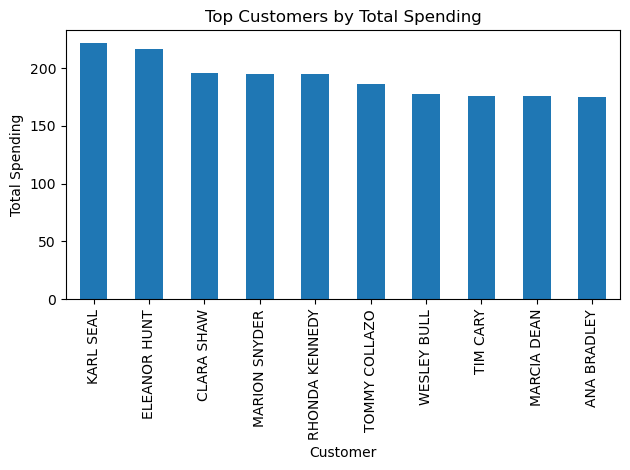

In [27]:
top_customers.plot(
    x="full_name",
    y="total_spending",
    kind="bar",
    legend=False,
    title="Top Customers by Total Spending"
)

plt.xlabel("Customer")
plt.ylabel("Total Spending")
plt.tight_layout()
plt.show()